In [1]:
# Check GPU and PyTorch setup

import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("⚠️ GPU is not enabled. Please enable GPU in Runtime settings.")

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8


In [2]:
# ============================================
# 2. Import Required Libraries
# ============================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

from torchvision import datasets, transforms

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# ============================================
# 3. Install KaggleHub
# ============================================

!pip -q install -U kagglehub

print("KaggleHub installed successfully!")

KaggleHub installed successfully!


In [4]:
 import getpass
import os

os.environ["KAGGLE_API_TOKEN"] = getpass.getpass("Enter your Kaggle API token: ")

Enter your Kaggle API token: ··········


In [5]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "masoudnickparvar/brain-tumor-mri-dataset"
)

print("Dataset downloaded to:")
print(dataset_path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset downloaded to:
/kaggle/input/brain-tumor-mri-dataset


In [6]:
# ============================================
# 4. Inspect Dataset Structure
# ============================================

import os

DATASET_PATH = "/kaggle/input/brain-tumor-mri-dataset"

print("Dataset contents:")
print(os.listdir(DATASET_PATH))

Dataset contents:
['Training', 'Testing']


In [7]:
# Display folder structure

for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)

    if level <= 2:
        indent = "    " * level
        print(f"{indent}{os.path.basename(root)}/")

        if level == 2:
            print(f"{indent}    Images: {len(files)}")

brain-tumor-mri-dataset/
    Training/
        pituitary/
            Images: 1400
        notumor/
            Images: 1400
        meningioma/
            Images: 1400
        glioma/
            Images: 1400
    Testing/
        pituitary/
            Images: 400
        notumor/
            Images: 400
        meningioma/
            Images: 400
        glioma/
            Images: 400


In [8]:
# ============================================
# 5. Image Transformations
# ============================================

from torchvision import transforms

IMAGE_SIZE = 224

# Training transformations
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation & Testing transformations
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully!")

Transforms created successfully!


In [9]:
# ============================================
# 6. Load Training and Testing Datasets
# ============================================

from torchvision.datasets import ImageFolder

TRAIN_PATH = os.path.join(DATASET_PATH, "Training")
TEST_PATH = os.path.join(DATASET_PATH, "Testing")

full_train_dataset = ImageFolder(
    root=TRAIN_PATH,
    transform=train_transform
)

test_dataset = ImageFolder(
    root=TEST_PATH,
    transform=test_transform
)

print("Total training images:", len(full_train_dataset))
print("Total testing images:", len(test_dataset))

print("\nClasses:")
print(full_train_dataset.classes)

Total training images: 5600
Total testing images: 1600

Classes:
['glioma', 'meningioma', 'notumor', 'pituitary']


In [10]:
# ============================================
# 7. Create Train / Validation Split
# ============================================

from torch.utils.data import random_split, Subset
from torchvision.datasets import ImageFolder

# Load the dataset without transformations first
base_dataset = ImageFolder(
    root=TRAIN_PATH,
    transform=None
)

# Reproducible split
train_size = int(0.8 * len(base_dataset))
val_size = len(base_dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_subset, val_subset = random_split(
    base_dataset,
    [train_size, val_size],
    generator=generator
)

print("Training images:", len(train_subset))
print("Validation images:", len(val_subset))
print("Testing images:", len(test_dataset))

Training images: 4480
Validation images: 1120
Testing images: 1600


In [11]:
# ============================================
# 8. Apply Train / Validation Transforms
# ============================================

class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, index):
        image, label = self.subset[index]

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = TransformedSubset(
    train_subset,
    transform=train_transform
)

val_dataset = TransformedSubset(
    val_subset,
    transform=test_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 4480
Validation dataset: 1120
Test dataset: 1600


In [12]:
# ============================================
# 9. Create DataLoaders
# ============================================

from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created successfully!")
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

DataLoaders created successfully!
Training batches: 140
Validation batches: 35
Testing batches: 50


In [13]:
# ============================================
# 10. Configure Device
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU Memory:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")

Device: cuda
GPU: Tesla T4
GPU Memory: 14.56 GB


In [14]:
# ============================================
# 11. Verify One Batch
# ============================================

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image data type:", images.dtype)
print("Label data type:", labels.dtype)
print("Image value range:", images.min().item(), "to", images.max().item())
print("Labels in batch:", labels.unique().tolist())

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image data type: torch.float32
Label data type: torch.int64
Image value range: -2.1179039478302 to 2.640000104904175
Labels in batch: [0, 1, 2, 3]


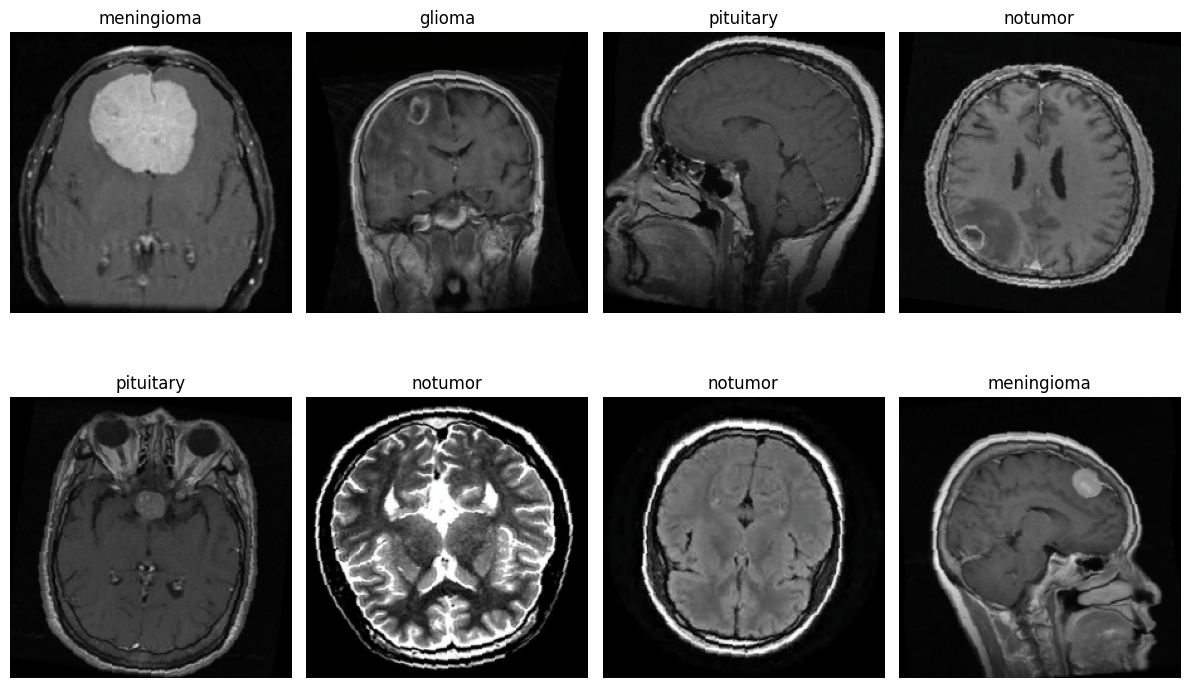

In [15]:
# ============================================
# 12. Visualize Sample Training Images
# ============================================

import matplotlib.pyplot as plt
import numpy as np

class_names = full_train_dataset.classes

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(8):
    image = images[i].permute(1, 2, 0).numpy()

    # Undo normalization for visualization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image * std + mean
    image = np.clip(image, 0, 1)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(class_names[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# ============================================
# 13. Define CNN Architecture
# ============================================

class BrainTumorCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(BrainTumorCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Create model
model = BrainTumorCNN(num_classes=4)

# Move model to GPU
model = model.to(device)

print(model)

BrainTumorCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

In [17]:
# ============================================
# 14. Model Parameter Count
# ============================================

total_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 422,788


In [18]:
# ============================================
# 15. Loss Function and Optimizer
# ============================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=0.0001
)

NUM_EPOCHS = 10

print("Loss function:", criterion)
print("Optimizer:", optimizer)
print("Number of epochs:", NUM_EPOCHS)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Number of epochs: 10


In [19]:
# ============================================
# 16. Final GPU Check
# ============================================

print("Training device:", device)
print("Model device:", next(model.parameters()).device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Training device: cuda
Model device: cuda:0
GPU: Tesla T4


In [20]:
# ============================================
# 17. Train CNN Model
# ============================================

import time

# Store training history
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# Track the best model
best_val_accuracy = 0.0
best_model_path = "/content/best_brain_tumor_cnn.pth"

print("Starting training...")
print("=" * 70)

for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    # ----------------------------------------
    # Training
    # ----------------------------------------
    model.train()

    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:

        # Move data to GPU
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_train_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / total_train
    epoch_train_accuracy = 100 * correct_train / total_train

    # ----------------------------------------
    # Validation
    # ----------------------------------------
    model.eval()

    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / total_val
    epoch_val_accuracy = 100 * correct_val / total_val

    # ----------------------------------------
    # Save history
    # ----------------------------------------
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    # ----------------------------------------
    # Save best model
    # ----------------------------------------
    if epoch_val_accuracy > best_val_accuracy:

        best_val_accuracy = epoch_val_accuracy

        torch.save(model.state_dict(), best_model_path)

        best_marker = " ← Best Model Saved"
    else:
        best_marker = ""

    # ----------------------------------------
    # Epoch time
    # ----------------------------------------
    epoch_time = time.time() - start_time

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] "
        f"| Train Loss: {epoch_train_loss:.4f} "
        f"| Train Acc: {epoch_train_accuracy:.2f}% "
        f"| Val Loss: {epoch_val_loss:.4f} "
        f"| Val Acc: {epoch_val_accuracy:.2f}% "
        f"| Time: {epoch_time:.1f}s"
        f"{best_marker}"
    )

print("=" * 70)
print("Training completed!")
print(f"Best Validation Accuracy: {best_val_accuracy:.2f}%")
print(f"Best model saved at: {best_model_path}")

Starting training...
Epoch [01/10] | Train Loss: 0.7946 | Train Acc: 68.19% | Val Loss: 1.0642 | Val Acc: 61.96% | Time: 39.0s ← Best Model Saved
Epoch [02/10] | Train Loss: 0.6512 | Train Acc: 73.95% | Val Loss: 1.3172 | Val Acc: 47.77% | Time: 30.1s
Epoch [03/10] | Train Loss: 0.5695 | Train Acc: 78.73% | Val Loss: 0.6992 | Val Acc: 75.00% | Time: 28.7s ← Best Model Saved
Epoch [04/10] | Train Loss: 0.5495 | Train Acc: 79.26% | Val Loss: 0.5132 | Val Acc: 77.50% | Time: 29.1s ← Best Model Saved
Epoch [05/10] | Train Loss: 0.5115 | Train Acc: 80.56% | Val Loss: 1.2690 | Val Acc: 60.98% | Time: 29.1s
Epoch [06/10] | Train Loss: 0.4782 | Train Acc: 81.67% | Val Loss: 0.5660 | Val Acc: 74.20% | Time: 28.8s
Epoch [07/10] | Train Loss: 0.4640 | Train Acc: 82.63% | Val Loss: 0.7678 | Val Acc: 68.21% | Time: 35.6s
Epoch [08/10] | Train Loss: 0.4412 | Train Acc: 83.26% | Val Loss: 0.4827 | Val Acc: 81.34% | Time: 28.9s ← Best Model Saved
Epoch [09/10] | Train Loss: 0.4306 | Train Acc: 84.15% 

In [21]:
# ============================================
# 18. Load Best Model
# ============================================

best_model = BrainTumorCNN(num_classes=4)

best_model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

best_model = best_model.to(device)
best_model.eval()

print("Best model loaded successfully!")
print(f"Best validation accuracy: {best_val_accuracy:.2f}%")

Best model loaded successfully!
Best validation accuracy: 81.34%


In [22]:
# ============================================
# 19. Evaluate Best Model on Test Set
# ============================================

best_model.eval()

test_loss = 0.0
correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = best_model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        _, predictions = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss = test_loss / total
test_accuracy = 100 * correct / total

print("=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Correct Predictions: {correct}/{total}")
print("=" * 60)

TEST SET RESULTS
Test Loss: 0.8114
Test Accuracy: 72.44%
Correct Predictions: 1159/1600


In [23]:
# ============================================
# 20. Classification Report
# ============================================

from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

      glioma     0.7120    0.6800    0.6957       400
  meningioma     0.6323    0.5675    0.5982       400
     notumor     0.6888    0.9850    0.8107       400
   pituitary     0.9268    0.6650    0.7744       400

    accuracy                         0.7244      1600
   macro avg     0.7400    0.7244    0.7197      1600
weighted avg     0.7400    0.7244    0.7197      1600



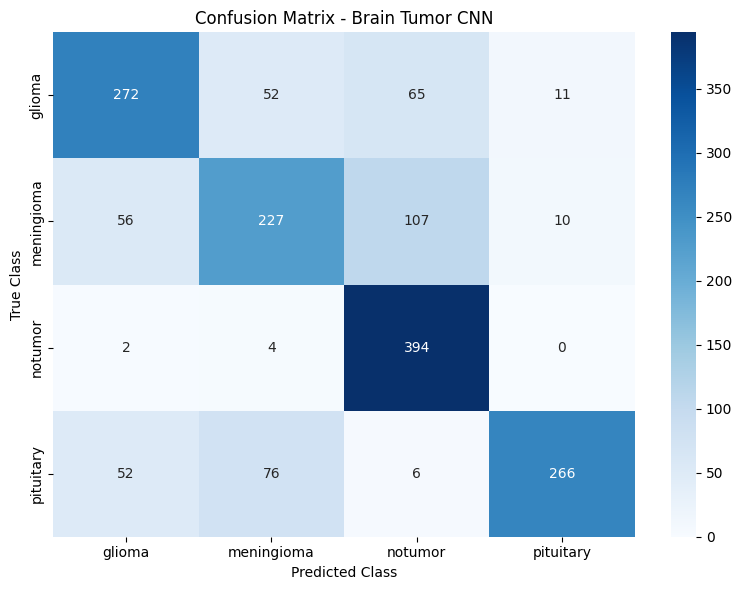

In [24]:
# ============================================
# 21. Confusion Matrix
# ============================================

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Brain Tumor CNN")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()

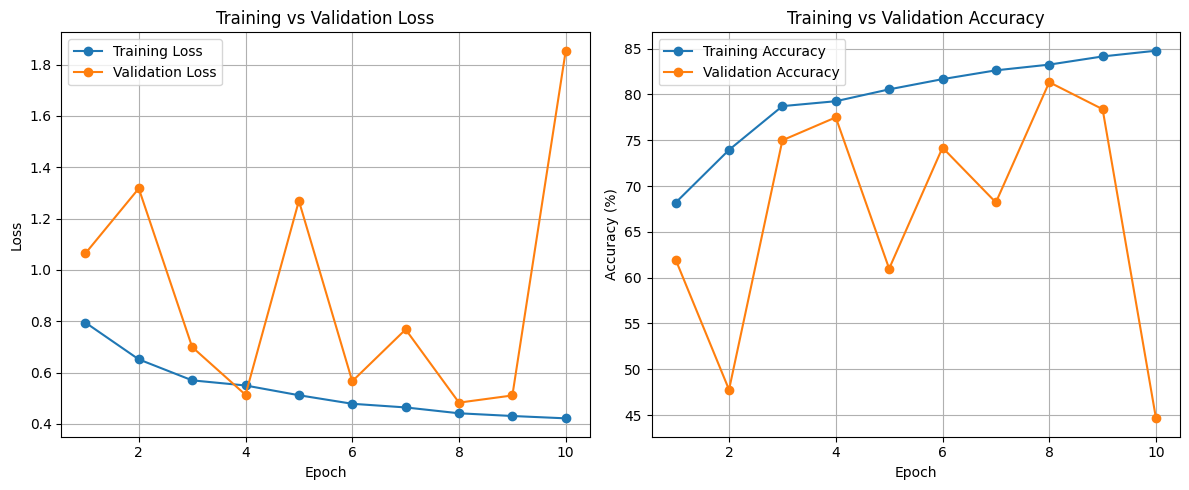

In [25]:
# ============================================
# 22. Training and Validation Curves
# ============================================

epochs_range = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(epochs_range, train_losses, marker='o', label='Training Loss')
plt.plot(epochs_range, val_losses, marker='o', label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)

plt.plot(epochs_range, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(epochs_range, val_accuracies, marker='o', label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [26]:
# ============================================
# 23. Check Train / Validation Class Distribution
# ============================================

from collections import Counter

# Original labels
all_targets = np.array(base_dataset.targets)

train_indices = train_subset.indices
val_indices = val_subset.indices

train_class_counts = Counter(all_targets[train_indices])
val_class_counts = Counter(all_targets[val_indices])

print("Class mapping:")
for idx, class_name in enumerate(base_dataset.classes):
    print(f"{idx}: {class_name}")

print("\nTraining class distribution:")
for idx, class_name in enumerate(base_dataset.classes):
    print(f"{class_name}: {train_class_counts[idx]}")

print("\nValidation class distribution:")
for idx, class_name in enumerate(base_dataset.classes):
    print(f"{class_name}: {val_class_counts[idx]}")

Class mapping:
0: glioma
1: meningioma
2: notumor
3: pituitary

Training class distribution:
glioma: 1115
meningioma: 1123
notumor: 1111
pituitary: 1131

Validation class distribution:
glioma: 285
meningioma: 277
notumor: 289
pituitary: 269


In [27]:
# ============================================
# 24. Stratified Train / Validation Split
# ============================================

from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

# Get all image indices and labels
indices = np.arange(len(base_dataset))
targets = np.array(base_dataset.targets)

# Stratified 80/20 split
train_indices, val_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=targets
)

print("Training images:", len(train_indices))
print("Validation images:", len(val_indices))
print("Testing images:", len(test_dataset))

Training images: 4480
Validation images: 1120
Testing images: 1600


In [28]:
# ============================================
# 25. Improved Image Transformations
# ============================================

train_transform_v2 = transforms.Compose([
    transforms.Resize((224, 224)),

    # Mild augmentation
    transforms.RandomRotation(7),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Create subsets
train_subset_v2 = Subset(base_dataset, train_indices)
val_subset_v2 = Subset(base_dataset, val_indices)

# Apply separate transforms
train_dataset_v2 = TransformedSubset(
    train_subset_v2,
    transform=train_transform_v2
)

val_dataset_v2 = TransformedSubset(
    val_subset_v2,
    transform=val_test_transform
)

print("Train dataset:", len(train_dataset_v2))
print("Validation dataset:", len(val_dataset_v2))

Train dataset: 4480
Validation dataset: 1120


In [29]:
# ============================================
# 26. Improved DataLoaders
# ============================================

BATCH_SIZE = 32

train_loader_v2 = DataLoader(
    train_dataset_v2,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_v2 = DataLoader(
    val_dataset_v2,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training batches:", len(train_loader_v2))
print("Validation batches:", len(val_loader_v2))

Training batches: 140
Validation batches: 35


In [30]:
# ============================================
# 27. Create Fresh Model
# ============================================

model_v2 = BrainTumorCNN(num_classes=4)

model_v2 = model_v2.to(device)

print("New model created.")
print("Device:", next(model_v2.parameters()).device)

total_params_v2 = sum(
    p.numel() for p in model_v2.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {total_params_v2:,}")

New model created.
Device: cuda:0
Trainable parameters: 422,788


In [31]:
# ============================================
# 28. Improved Loss, Optimizer and Scheduler
# ============================================

criterion_v2 = nn.CrossEntropyLoss()

optimizer_v2 = optim.Adam(
    model_v2.parameters(),
    lr=0.0003,
    weight_decay=0.0001
)

scheduler_v2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v2,
    mode='min',
    factor=0.5,
    patience=2
)

NUM_EPOCHS_V2 = 10

print("Learning rate:", optimizer_v2.param_groups[0]['lr'])
print("Weight decay:", 0.0001)
print("Scheduler: ReduceLROnPlateau")
print("Epochs:", NUM_EPOCHS_V2)

Learning rate: 0.0003
Weight decay: 0.0001
Scheduler: ReduceLROnPlateau
Epochs: 10


In [ ]:
# ============================================
# 29. Train CNN - Experiment 2
# ============================================

import time

train_losses_v2 = []
train_accuracies_v2 = []
val_losses_v2 = []
val_accuracies_v2 = []
learning_rates_v2 = []

best_val_accuracy_v2 = 0.0
best_model_path_v2 = "/content/best_brain_tumor_cnn_v2.pth"

print("Starting Experiment 2 training...")
print("=" * 80)

for epoch in range(NUM_EPOCHS_V2):

    start_time = time.time()

    # ----------------------------------------
    # Training
    # ----------------------------------------
    model_v2.train()

    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader_v2:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer_v2.zero_grad()

        outputs = model_v2(images)

        loss = criterion_v2(outputs, labels)

        loss.backward()

        optimizer_v2.step()

        running_train_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / total_train
    epoch_train_accuracy = 100 * correct_train / total_train

    # ----------------------------------------
    # Validation
    # ----------------------------------------
    model_v2.eval()

    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for images, labels in val_loader_v2:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model_v2(images)

            loss = criterion_v2(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / total_val
    epoch_val_accuracy = 100 * correct_val / total_val

    # ----------------------------------------
    # Learning-rate scheduler
    # ----------------------------------------
    scheduler_v2.step(epoch_val_loss)

    current_lr = optimizer_v2.param_groups[0]['lr']

    # ----------------------------------------
    # Save history
    # ----------------------------------------
    train_losses_v2.append(epoch_train_loss)
    train_accuracies_v2.append(epoch_train_accuracy)

    val_losses_v2.append(epoch_val_loss)
    val_accuracies_v2.append(epoch_val_accuracy)
    learning_rates_v2.append(current_lr)

    # ----------------------------------------
    # Save best model
    # ----------------------------------------
    if epoch_val_accuracy > best_val_accuracy_v2:

        best_val_accuracy_v2 = epoch_val_accuracy

        torch.save(
            model_v2.state_dict(),
            best_model_path_v2
        )

        best_marker = " ← Best Model Saved"

    else:
        best_marker = ""

    epoch_time = time.time() - start_time

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS_V2}] "
        f"| Train Loss: {epoch_train_loss:.4f} "
        f"| Train Acc: {epoch_train_accuracy:.2f}% "
        f"| Val Loss: {epoch_val_loss:.4f} "
        f"| Val Acc: {epoch_val_accuracy:.2f}% "
        f"| LR: {current_lr:.6f} "
        f"| Time: {epoch_time:.1f}s"
        f"{best_marker}"
    )

print("=" * 80)
print("Experiment 2 training completed!")
print(f"Best Validation Accuracy: {best_val_accuracy_v2:.2f}%")
print(f"Best model saved at: {best_model_path_v2}")

Starting Experiment 2 training...
Epoch [01/10] | Train Loss: 0.8825 | Train Acc: 65.18% | Val Loss: 1.1771 | Val Acc: 54.11% | LR: 0.000300 | Time: 28.8s ← Best Model Saved
Epoch [02/10] | Train Loss: 0.6797 | Train Acc: 73.26% | Val Loss: 0.6192 | Val Acc: 75.71% | LR: 0.000300 | Time: 29.1s ← Best Model Saved
Epoch [03/10] | Train Loss: 0.5792 | Train Acc: 77.59% | Val Loss: 0.6188 | Val Acc: 77.32% | LR: 0.000300 | Time: 28.2s ← Best Model Saved
Epoch [04/10] | Train Loss: 0.5372 | Train Acc: 79.80% | Val Loss: 0.6414 | Val Acc: 70.18% | LR: 0.000300 | Time: 28.3s
Epoch [05/10] | Train Loss: 0.4809 | Train Acc: 82.14% | Val Loss: 0.6098 | Val Acc: 75.71% | LR: 0.000300 | Time: 28.3s
Epoch [06/10] | Train Loss: 0.4433 | Train Acc: 83.68% | Val Loss: 1.0001 | Val Acc: 67.05% | LR: 0.000300 | Time: 28.3s
Epoch [07/10] | Train Loss: 0.4478 | Train Acc: 83.42% | Val Loss: 0.6715 | Val Acc: 76.25% | LR: 0.000300 | Time: 29.1s
Epoch [08/10] | Train Loss: 0.4118 | Train Acc: 84.64% | Val L

In [ ]:
# ============================================
# 30. Load Best Experiment 2 Model
# ============================================

best_model_v2 = BrainTumorCNN(num_classes=4)

best_model_v2.load_state_dict(
    torch.load(
        best_model_path_v2,
        map_location=device
    )
)

best_model_v2 = best_model_v2.to(device)
best_model_v2.eval()

print("Best Experiment 2 model loaded!")
print(f"Best validation accuracy: {best_val_accuracy_v2:.2f}%")

In [34]:
# ============================================
# 31. Evaluate Experiment 2 on Test Set
# ============================================

test_loss_v2 = 0.0
correct_v2 = 0
total_v2 = 0

all_predictions_v2 = []
all_labels_v2 = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = best_model_v2(images)

        loss = criterion_v2(outputs, labels)

        test_loss_v2 += loss.item() * images.size(0)

        _, predictions = torch.max(outputs, 1)

        total_v2 += labels.size(0)
        correct_v2 += (predictions == labels).sum().item()

        all_predictions_v2.extend(
            predictions.cpu().numpy()
        )

        all_labels_v2.extend(
            labels.cpu().numpy()
        )

test_loss_v2 = test_loss_v2 / total_v2
test_accuracy_v2 = 100 * correct_v2 / total_v2

print("=" * 60)
print("EXPERIMENT 2 - TEST SET RESULTS")
print("=" * 60)
print(f"Test Loss: {test_loss_v2:.4f}")
print(f"Test Accuracy: {test_accuracy_v2:.2f}%")
print(f"Correct Predictions: {correct_v2}/{total_v2}")
print("=" * 60)

EXPERIMENT 2 - TEST SET RESULTS
Test Loss: 0.8754
Test Accuracy: 75.81%
Correct Predictions: 1213/1600


In [ ]:
# ============================================
# 32. Experiment 2 - Classification Report
# ============================================

from sklearn.metrics import classification_report

report_v2 = classification_report(
    all_labels_v2,
    all_predictions_v2,
    target_names=class_names,
    digits=4
)

print(report_v2)

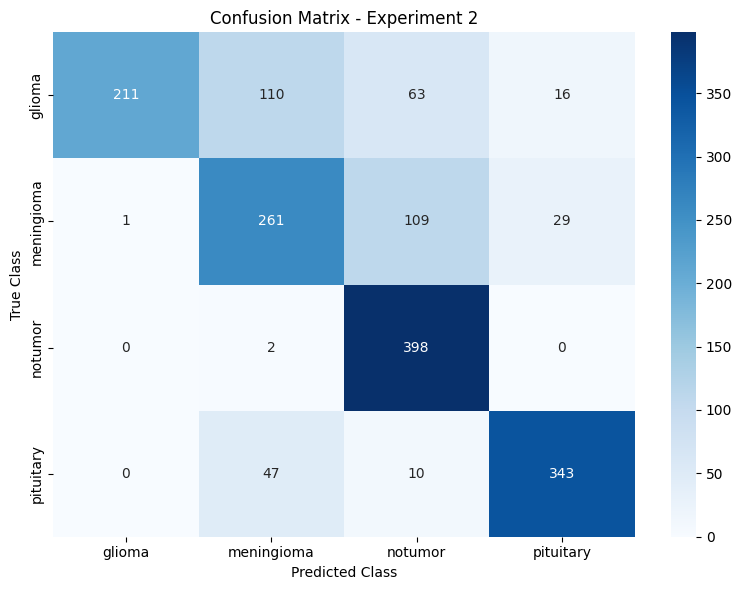

In [36]:
# ============================================
# 33. Experiment 2 - Confusion Matrix
# ============================================

cm_v2 = confusion_matrix(
    all_labels_v2,
    all_predictions_v2
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_v2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Experiment 2")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()

In [37]:
# ============================================
# 34. Import ResNet18
# ============================================

from torchvision import models

print("Torchvision version:", torchvision.__version__)

Torchvision version: 0.26.0+cu128


In [38]:
# ============================================
# 35. Load Pretrained ResNet18
# ============================================

weights = models.ResNet18_Weights.DEFAULT

resnet18 = models.resnet18(weights=weights)

print(resnet18)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [39]:
# ============================================
# ResNet18 — Required Imports
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models

import numpy as np
import matplotlib.pyplot as plt
import os
import time

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
CUDA available: True
GPU: Tesla T4


In [40]:
# ============================================
# 36. Modify ResNet18 Classifier
# ============================================

num_features = resnet18.fc.in_features

resnet18.fc = nn.Linear(
    num_features,
    4
)

resnet18 = resnet18.to(device)

print("Final classifier:")
print(resnet18.fc)

print("Model device:", next(resnet18.parameters()).device)

Final classifier:
Linear(in_features=512, out_features=4, bias=True)
Model device: cuda:0


In [41]:
# ============================================
# 37. ResNet18 Loss & Optimizer
# ============================================

criterion_resnet = nn.CrossEntropyLoss()

optimizer_resnet = optim.Adam(
    resnet18.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)

scheduler_resnet = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_resnet,
    mode="min",
    factor=0.5,
    patience=2
)

NUM_EPOCHS_RESNET = 10

print("Loss function:", criterion_resnet)
print("Learning rate:", 0.0001)
print("Weight decay:", 0.0001)
print("Epochs:", NUM_EPOCHS_RESNET)
print("Scheduler: ReduceLROnPlateau")

Loss function: CrossEntropyLoss()
Learning rate: 0.0001
Weight decay: 0.0001
Epochs: 10
Scheduler: ReduceLROnPlateau


In [42]:
# ============================================
# 38. ResNet18 Image Transformations
# ============================================

resnet_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(7),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

resnet_eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset_resnet = TransformedSubset(
    train_subset_v2,
    transform=resnet_train_transform
)

val_dataset_resnet = TransformedSubset(
    val_subset_v2,
    transform=resnet_eval_transform
)

print("ResNet training images:", len(train_dataset_resnet))
print("ResNet validation images:", len(val_dataset_resnet))

ResNet training images: 4480
ResNet validation images: 1120


In [43]:
# ============================================
# 39. ResNet18 DataLoaders
# ============================================

train_loader_resnet = DataLoader(
    train_dataset_resnet,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_resnet = DataLoader(
    val_dataset_resnet,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training batches:", len(train_loader_resnet))
print("Validation batches:", len(val_loader_resnet))

Training batches: 140
Validation batches: 35


In [44]:
# ============================================
# 40. Train ResNet18 - Experiment 3
# ============================================

import time

train_losses_resnet = []
train_accuracies_resnet = []
val_losses_resnet = []
val_accuracies_resnet = []
learning_rates_resnet = []

best_val_accuracy_resnet = 0.0

best_model_path_resnet = "/content/best_brain_tumor_resnet18.pth"

print("Starting Experiment 3 - ResNet18...")
print("=" * 85)

for epoch in range(NUM_EPOCHS_RESNET):

    start_time = time.time()

    # ----------------------------------------
    # Training
    # ----------------------------------------
    resnet18.train()

    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader_resnet:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer_resnet.zero_grad()

        outputs = resnet18(images)

        loss = criterion_resnet(outputs, labels)

        loss.backward()

        optimizer_resnet.step()

        running_train_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / total_train
    epoch_train_accuracy = 100 * correct_train / total_train

    # ----------------------------------------
    # Validation
    # ----------------------------------------
    resnet18.eval()

    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for images, labels in val_loader_resnet:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = resnet18(images)

            loss = criterion_resnet(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / total_val
    epoch_val_accuracy = 100 * correct_val / total_val

    # ----------------------------------------
    # Scheduler
    # ----------------------------------------
    scheduler_resnet.step(epoch_val_loss)

    current_lr = optimizer_resnet.param_groups[0]["lr"]

    # ----------------------------------------
    # Save history
    # ----------------------------------------
    train_losses_resnet.append(epoch_train_loss)
    train_accuracies_resnet.append(epoch_train_accuracy)

    val_losses_resnet.append(epoch_val_loss)
    val_accuracies_resnet.append(epoch_val_accuracy)

    learning_rates_resnet.append(current_lr)

    # ----------------------------------------
    # Save best model
    # ----------------------------------------
    if epoch_val_accuracy > best_val_accuracy_resnet:

        best_val_accuracy_resnet = epoch_val_accuracy

        torch.save(
            resnet18.state_dict(),
            best_model_path_resnet
        )

        best_marker = " ← Best Model Saved"

    else:
        best_marker = ""

    epoch_time = time.time() - start_time

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS_RESNET}] "
        f"| Train Loss: {epoch_train_loss:.4f} "
        f"| Train Acc: {epoch_train_accuracy:.2f}% "
        f"| Val Loss: {epoch_val_loss:.4f} "
        f"| Val Acc: {epoch_val_accuracy:.2f}% "
        f"| LR: {current_lr:.6f} "
        f"| Time: {epoch_time:.1f}s"
        f"{best_marker}"
    )

print("=" * 85)
print("Experiment 3 training completed!")
print(f"Best Validation Accuracy: {best_val_accuracy_resnet:.2f}%")
print(f"Best model saved at: {best_model_path_resnet}")

Starting Experiment 3 - ResNet18...
Epoch [01/10] | Train Loss: 0.2685 | Train Acc: 90.13% | Val Loss: 0.1031 | Val Acc: 96.70% | LR: 0.000100 | Time: 29.8s ← Best Model Saved
Epoch [02/10] | Train Loss: 0.0722 | Train Acc: 97.63% | Val Loss: 0.0727 | Val Acc: 97.59% | LR: 0.000100 | Time: 30.5s ← Best Model Saved
Epoch [03/10] | Train Loss: 0.0439 | Train Acc: 98.46% | Val Loss: 0.0478 | Val Acc: 98.39% | LR: 0.000100 | Time: 30.1s ← Best Model Saved
Epoch [04/10] | Train Loss: 0.0195 | Train Acc: 99.49% | Val Loss: 0.0560 | Val Acc: 97.95% | LR: 0.000100 | Time: 29.2s
Epoch [05/10] | Train Loss: 0.0274 | Train Acc: 99.17% | Val Loss: 0.0718 | Val Acc: 97.86% | LR: 0.000100 | Time: 29.3s
Epoch [06/10] | Train Loss: 0.0177 | Train Acc: 99.49% | Val Loss: 0.0570 | Val Acc: 97.86% | LR: 0.000050 | Time: 30.3s
Epoch [07/10] | Train Loss: 0.0113 | Train Acc: 99.73% | Val Loss: 0.0482 | Val Acc: 98.04% | LR: 0.000050 | Time: 29.3s
Epoch [08/10] | Train Loss: 0.0049 | Train Acc: 99.89% | Val

In [45]:
# ============================================
# 41. Load Best ResNet18 Model
# ============================================

best_resnet = models.resnet18(
    weights=None
)

best_resnet.fc = nn.Linear(
    best_resnet.fc.in_features,
    4
)

best_resnet.load_state_dict(
    torch.load(
        best_model_path_resnet,
        map_location=device
    )
)

best_resnet = best_resnet.to(device)
best_resnet.eval()

print("Best ResNet18 model loaded successfully!")
print(f"Best validation accuracy: {best_val_accuracy_resnet:.2f}%")

Best ResNet18 model loaded successfully!
Best validation accuracy: 99.11%


In [46]:
# ============================================
# 42. ResNet18 - Test Set Evaluation
# ============================================

test_loss_resnet = 0.0
correct_resnet = 0
total_resnet = 0

all_predictions_resnet = []
all_labels_resnet = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = best_resnet(images)

        loss = criterion_resnet(outputs, labels)

        test_loss_resnet += loss.item() * images.size(0)

        _, predictions = torch.max(outputs, 1)

        total_resnet += labels.size(0)
        correct_resnet += (predictions == labels).sum().item()

        all_predictions_resnet.extend(
            predictions.cpu().numpy()
        )

        all_labels_resnet.extend(
            labels.cpu().numpy()
        )

test_loss_resnet = test_loss_resnet / total_resnet
test_accuracy_resnet = 100 * correct_resnet / total_resnet

print("=" * 65)
print("EXPERIMENT 3 - RESNET18 TEST RESULTS")
print("=" * 65)
print(f"Test Loss: {test_loss_resnet:.4f}")
print(f"Test Accuracy: {test_accuracy_resnet:.2f}%")
print(f"Correct Predictions: {correct_resnet}/{total_resnet}")
print("=" * 65)

EXPERIMENT 3 - RESNET18 TEST RESULTS
Test Loss: 0.3179
Test Accuracy: 94.56%
Correct Predictions: 1513/1600


In [47]:
# ============================================
# 43. ResNet18 Classification Report
# ============================================

from sklearn.metrics import classification_report

report_resnet = classification_report(
    all_labels_resnet,
    all_predictions_resnet,
    target_names=class_names,
    digits=4
)

print(report_resnet)

              precision    recall  f1-score   support

      glioma     0.9969    0.8125    0.8953       400
  meningioma     0.9155    0.9750    0.9443       400
     notumor     0.9009    1.0000    0.9479       400
   pituitary     0.9851    0.9950    0.9900       400

    accuracy                         0.9456      1600
   macro avg     0.9496    0.9456    0.9444      1600
weighted avg     0.9496    0.9456    0.9444      1600



Confusion Matrix:
[[325  34  41   0]
 [  1 390   3   6]
 [  0   0 400   0]
 [  0   2   0 398]]


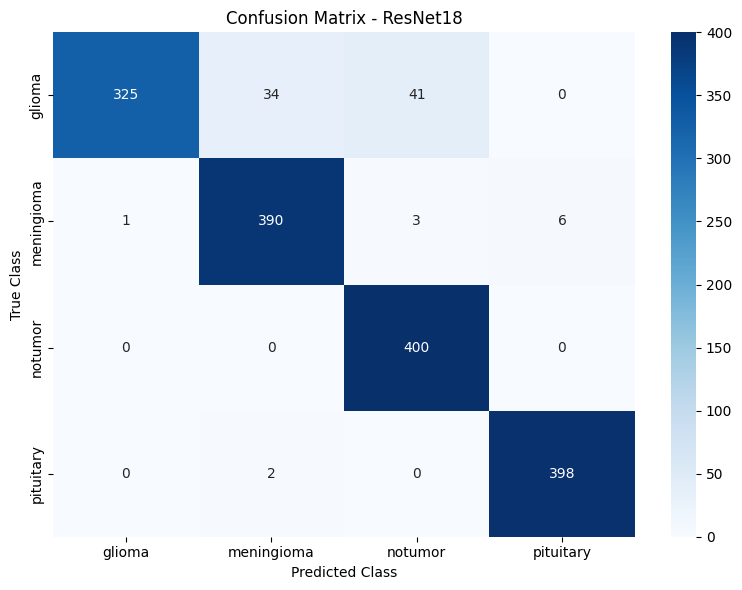

In [48]:
# ============================================
# 44. ResNet18 Confusion Matrix
# ============================================

cm_resnet = confusion_matrix(
    all_labels_resnet,
    all_predictions_resnet
)

print("Confusion Matrix:")
print(cm_resnet)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_resnet,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - ResNet18")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()

In [49]:
# ============================================
# 45. Prepare ResNet18 for Grad-CAM
# ============================================

best_resnet.eval()

target_layer = best_resnet.layer4[-1]

print("Model:", "ResNet18")
print("Target Grad-CAM layer:", target_layer)
print("Model device:", next(best_resnet.parameters()).device)

Model: ResNet18
Target Grad-CAM layer: BasicBlock(
  (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)
Model device: cuda:0


In [50]:
# ============================================
# 46. Grad-CAM Implementation
# ============================================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        # Forward hook
        self.forward_hook = target_layer.register_forward_hook(
            self.save_activations
        )

        # Backward hook
        self.backward_hook = target_layer.register_full_backward_hook(
            self.save_gradients
        )

    def save_activations(self, module, input, output):
        self.activations = output

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, image_tensor, class_index=None):

        self.model.eval()

        # Clear gradients
        self.model.zero_grad()

        # Forward pass
        output = self.model(image_tensor)

        # If no class is specified, use predicted class
        if class_index is None:
            class_index = output.argmax(dim=1).item()

        # Score for target class
        target_score = output[:, class_index]

        # Backward pass
        target_score.backward()

        # Get activations and gradients
        activations = self.activations
        gradients = self.gradients

        # Global average pooling of gradients
        weights = gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        # Weighted combination of feature maps
        cam = (weights * activations).sum(dim=1)

        # ReLU
        cam = torch.relu(cam)

        # Remove batch dimension
        cam = cam[0]

        # Normalize between 0 and 1
        cam -= cam.min()

        if cam.max() > 0:
            cam /= cam.max()

        return cam.detach().cpu().numpy(), class_index

In [51]:
# ============================================
# 47. Initialize Grad-CAM
# ============================================

gradcam = GradCAM(
    model=best_resnet,
    target_layer=target_layer
)

print("Grad-CAM initialized successfully!")

Grad-CAM initialized successfully!


In [52]:
# ============================================
# 48. Select Test Image
# ============================================

test_image, test_label = test_dataset[0]

# Add batch dimension and move to GPU
input_tensor = test_image.unsqueeze(0).to(device)

print("Image shape:", test_image.shape)
print("True class:", class_names[test_label])

Image shape: torch.Size([3, 224, 224])
True class: glioma


In [53]:
# ============================================
# 49. Generate Grad-CAM
# ============================================

heatmap, predicted_class = gradcam.generate(
    input_tensor
)

print("True class:", class_names[test_label])
print("Predicted class:", class_names[predicted_class])
print("Heatmap shape:", heatmap.shape)

True class: glioma
Predicted class: notumor
Heatmap shape: (7, 7)


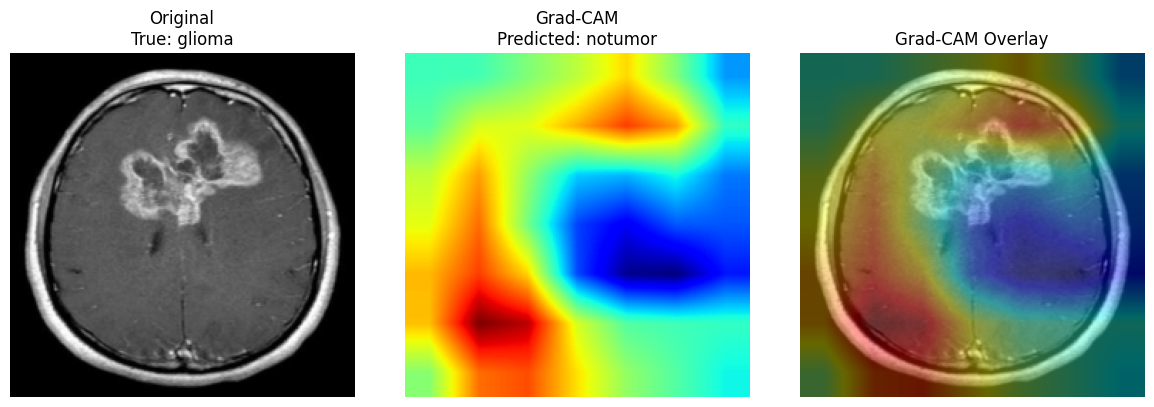

In [54]:
# ============================================
# 50. Visualize Grad-CAM
# ============================================

import cv2

# Convert normalized tensor back to image
image = test_image.permute(1, 2, 0).numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

image = image * std + mean
image = np.clip(image, 0, 1)

# Convert heatmap to 224x224
heatmap_resized = cv2.resize(
    heatmap,
    (224, 224)
)

# Convert to uint8
heatmap_uint8 = np.uint8(
    255 * heatmap_resized
)

# Apply OpenCV heatmap
heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

# Convert BGR → RGB
heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# Convert original image to uint8
original_uint8 = np.uint8(
    image * 255
)

# Overlay
overlay = cv2.addWeighted(
    original_uint8,
    0.6,
    heatmap_color,
    0.4,
    0
)

# Display
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title(
    f"Original\nTrue: {class_names[test_label]}"
)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title(
    f"Grad-CAM\nPredicted: {class_names[predicted_class]}"
)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [55]:
# ============================================
# 51. Grad-CAM Visualization Function
# ============================================

def visualize_gradcam(
    dataset,
    index,
    model,
    gradcam,
    class_names,
    device
):
    # Get image and true label
    image_tensor, true_label = dataset[index]

    # Add batch dimension
    input_tensor = image_tensor.unsqueeze(0).to(device)

    # Generate Grad-CAM
    heatmap, predicted_class = gradcam.generate(
        input_tensor
    )

    # Convert normalized tensor back to image
    image = image_tensor.permute(1, 2, 0).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image * std + mean
    image = np.clip(image, 0, 1)

    # Resize heatmap
    heatmap_resized = cv2.resize(
        heatmap,
        (224, 224)
    )

    # Convert heatmap
    heatmap_uint8 = np.uint8(
        255 * heatmap_resized
    )

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    # Original image
    original_uint8 = np.uint8(
        image * 255
    )

    # Overlay
    overlay = cv2.addWeighted(
        original_uint8,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    # Display
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title(
        f"Original MRI\n"
        f"True: {class_names[true_label]}"
    )
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title(
        f"Grad-CAM Heatmap\n"
        f"Predicted: {class_names[predicted_class]}"
    )
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Grad-CAM Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("True class     :", class_names[true_label])
    print("Predicted class:", class_names[predicted_class])
    print(
        "Prediction:",
        "CORRECT" if true_label == predicted_class else "INCORRECT"
    )

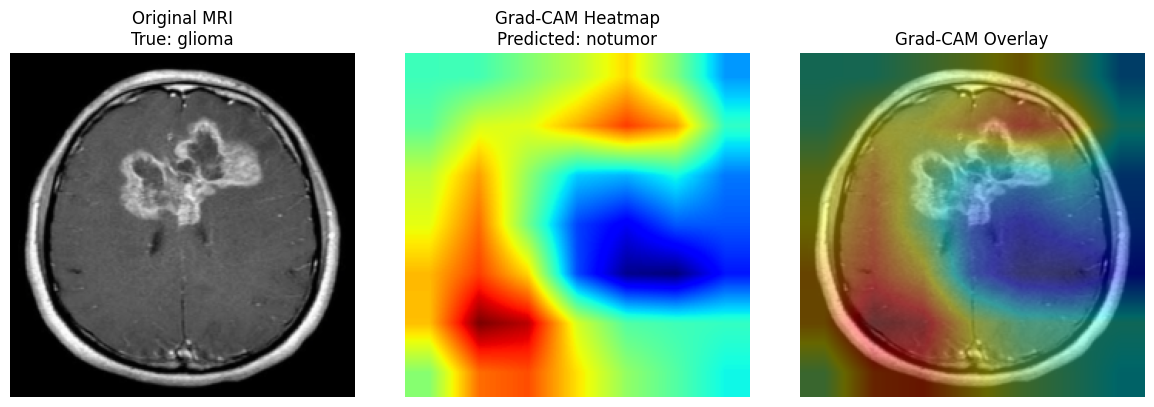

True class     : glioma
Predicted class: notumor
Prediction: INCORRECT


In [56]:
# ============================================
# 52. Test Grad-CAM on One Test Image
# ============================================

test_index = 0

visualize_gradcam(
    dataset=test_dataset,
    index=test_index,
    model=best_resnet,
    gradcam=gradcam,
    class_names=class_names,
    device=device
)


Test Image Index: 0


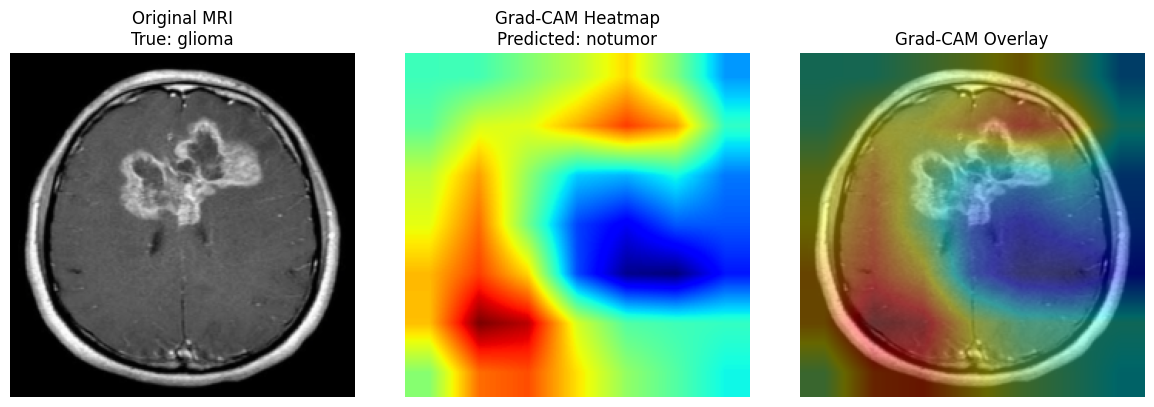

True class     : glioma
Predicted class: notumor
Prediction: INCORRECT

Test Image Index: 100


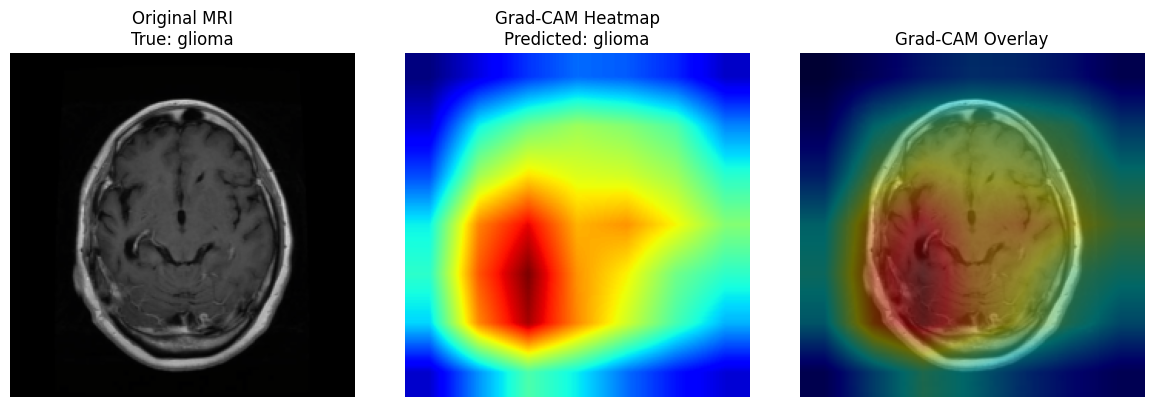

True class     : glioma
Predicted class: glioma
Prediction: CORRECT

Test Image Index: 200


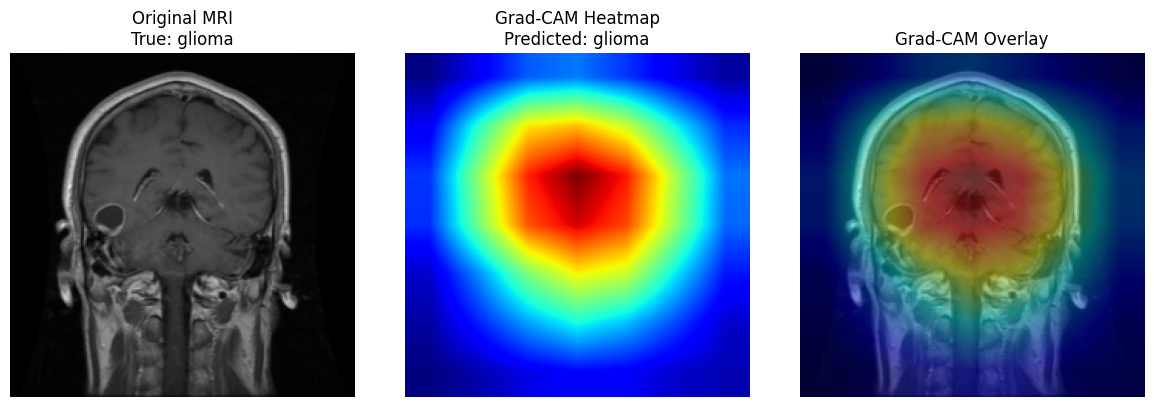

True class     : glioma
Predicted class: glioma
Prediction: CORRECT

Test Image Index: 300


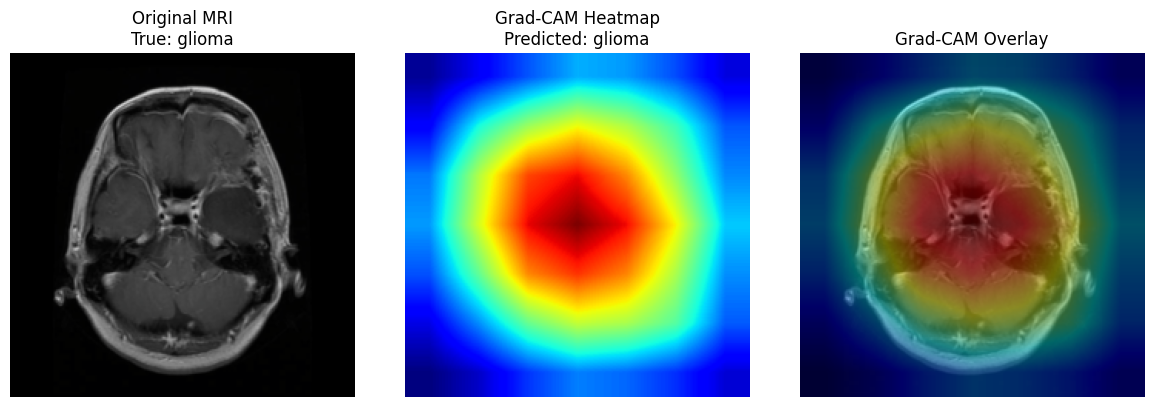

True class     : glioma
Predicted class: glioma
Prediction: CORRECT

Test Image Index: 500


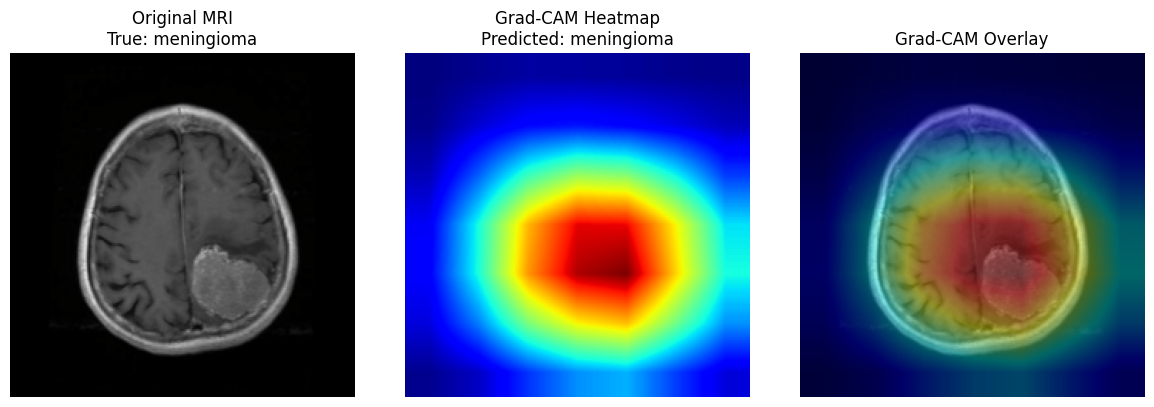

True class     : meningioma
Predicted class: meningioma
Prediction: CORRECT

Test Image Index: 700


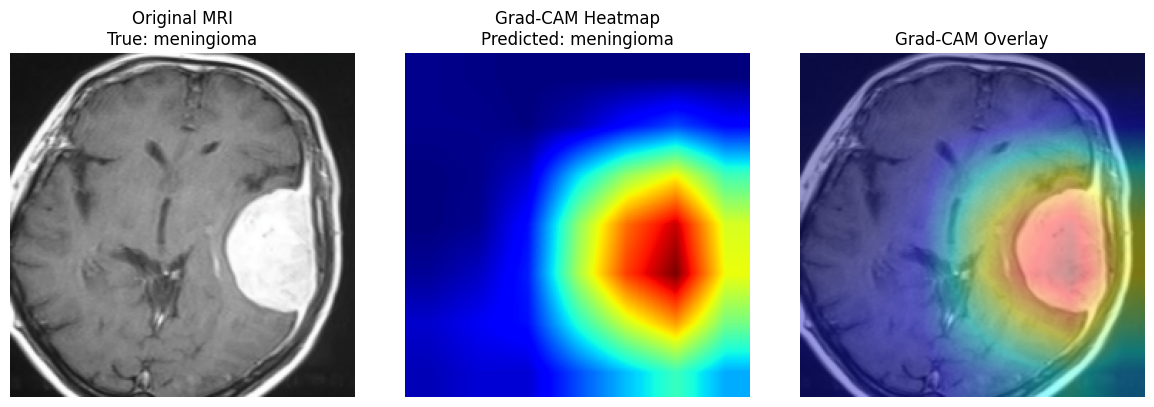

True class     : meningioma
Predicted class: meningioma
Prediction: CORRECT

Test Image Index: 1000


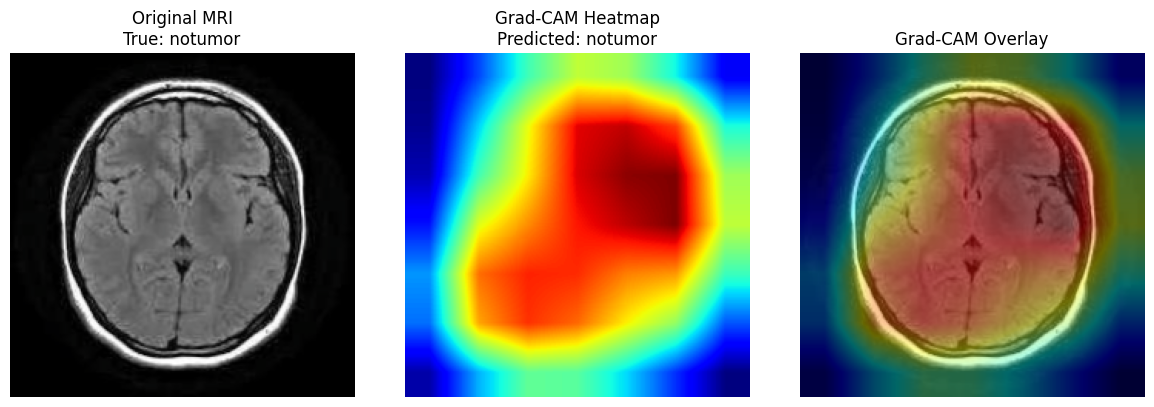

True class     : notumor
Predicted class: notumor
Prediction: CORRECT

Test Image Index: 1200


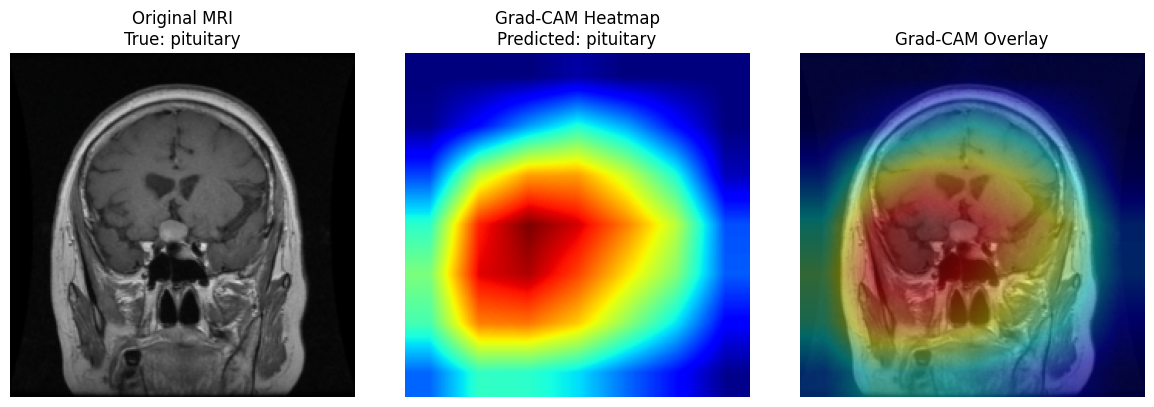

True class     : pituitary
Predicted class: pituitary
Prediction: CORRECT


In [57]:
# ============================================
# 53. Grad-CAM on Multiple Test Images
# ============================================

sample_indices = [0, 100, 200, 300, 500, 700, 1000, 1200]

for idx in sample_indices:

    print("\n" + "=" * 70)
    print(f"Test Image Index: {idx}")
    print("=" * 70)

    visualize_gradcam(
        dataset=test_dataset,
        index=idx,
        model=best_resnet,
        gradcam=gradcam,
        class_names=class_names,
        device=device
    )

In [58]:
# ============================================
# 54. Find Correct and Incorrect Predictions
# ============================================

correct_indices = []
incorrect_indices = []

best_resnet.eval()

for idx in range(len(test_dataset)):

    image, true_label = test_dataset[idx]

    input_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = best_resnet(input_tensor)

    predicted_label = output.argmax(dim=1).item()

    if predicted_label == true_label:
        correct_indices.append(idx)
    else:
        incorrect_indices.append(idx)

print("Total test images:", len(test_dataset))
print("Correct predictions:", len(correct_indices))
print("Incorrect predictions:", len(incorrect_indices))

print("\nFirst 10 correct indices:")
print(correct_indices[:10])

print("\nFirst 10 incorrect indices:")
print(incorrect_indices[:10])

Total test images: 1600
Correct predictions: 1513
Incorrect predictions: 87

First 10 correct indices:
[1, 2, 3, 5, 6, 7, 9, 10, 12, 13]

First 10 incorrect indices:
[0, 4, 8, 11, 18, 30, 33, 38, 46, 49]



Incorrect Prediction - Index: 0


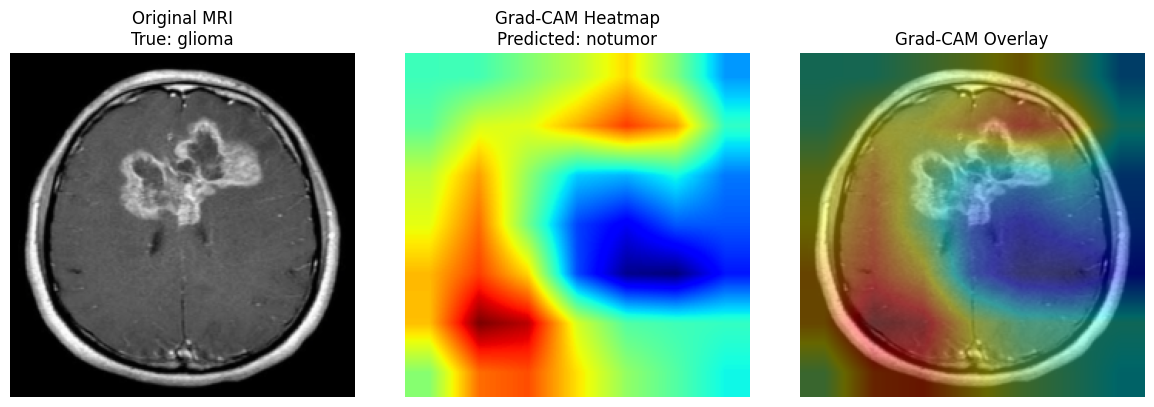

True class     : glioma
Predicted class: notumor
Prediction: INCORRECT

Incorrect Prediction - Index: 4


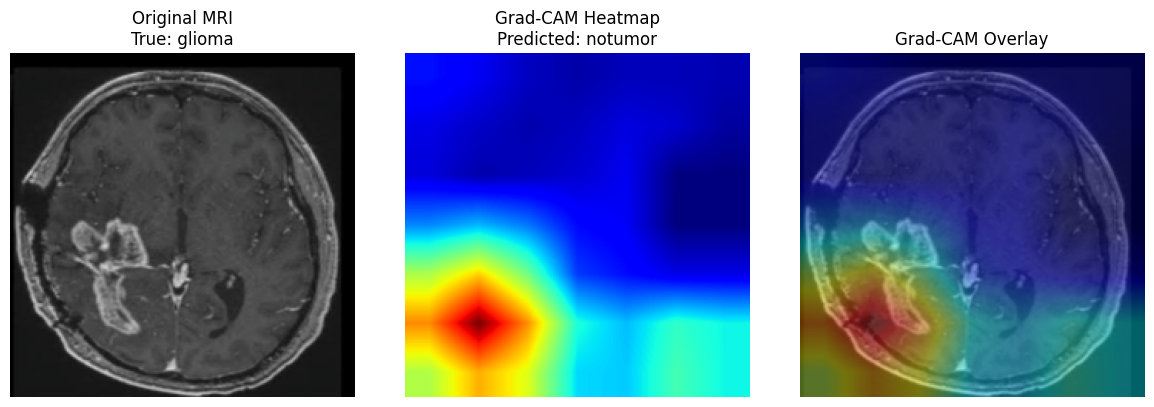

True class     : glioma
Predicted class: notumor
Prediction: INCORRECT

Incorrect Prediction - Index: 8


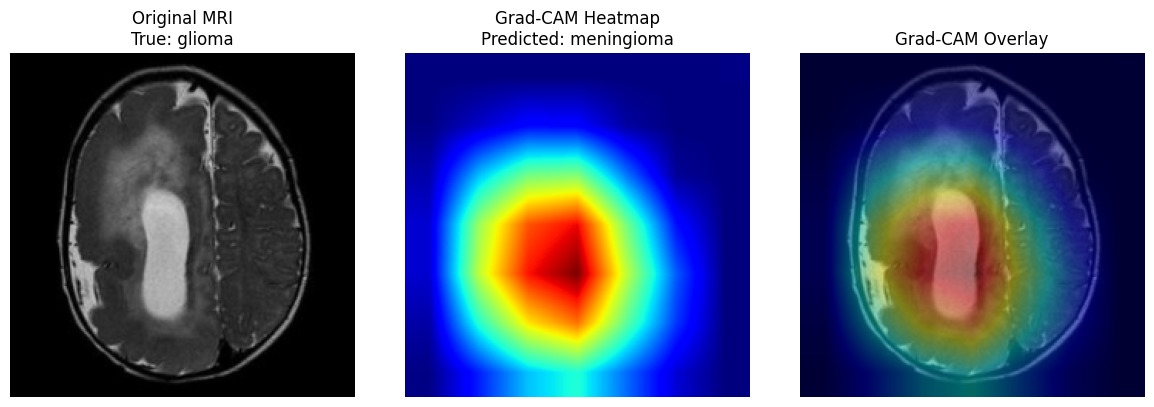

True class     : glioma
Predicted class: meningioma
Prediction: INCORRECT


In [59]:
# ============================================
# 55. Grad-CAM on Incorrect Predictions
# ============================================

for idx in incorrect_indices[:3]:

    print("\n" + "=" * 70)
    print(f"Incorrect Prediction - Index: {idx}")
    print("=" * 70)

    visualize_gradcam(
        dataset=test_dataset,
        index=idx,
        model=best_resnet,
        gradcam=gradcam,
        class_names=class_names,
        device=device
    )


Correct Prediction - Index: 1


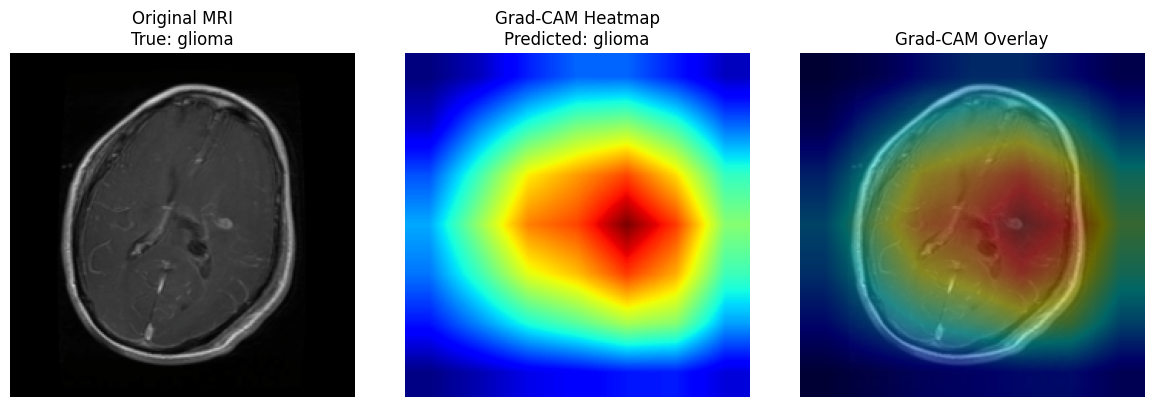

True class     : glioma
Predicted class: glioma
Prediction: CORRECT

Correct Prediction - Index: 2


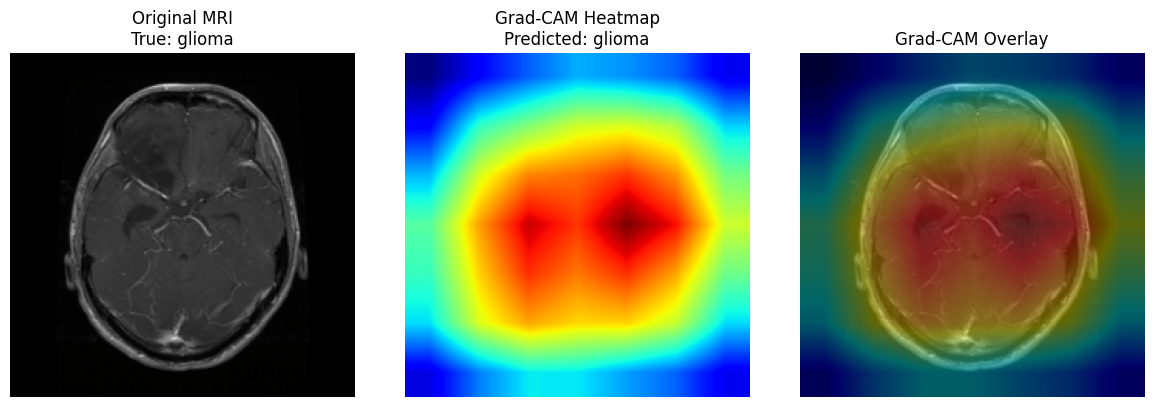

True class     : glioma
Predicted class: glioma
Prediction: CORRECT

Correct Prediction - Index: 3


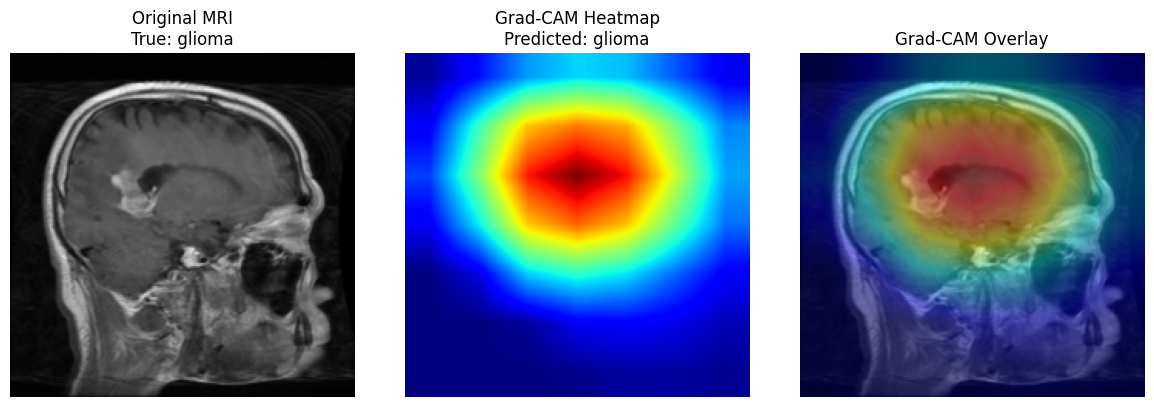

True class     : glioma
Predicted class: glioma
Prediction: CORRECT


In [60]:
# ============================================
# 56. Grad-CAM on Correct Predictions
# ============================================

for idx in correct_indices[:3]:

    print("\n" + "=" * 70)
    print(f"Correct Prediction - Index: {idx}")
    print("=" * 70)

    visualize_gradcam(
        dataset=test_dataset,
        index=idx,
        model=best_resnet,
        gradcam=gradcam,
        class_names=class_names,
        device=device
    )

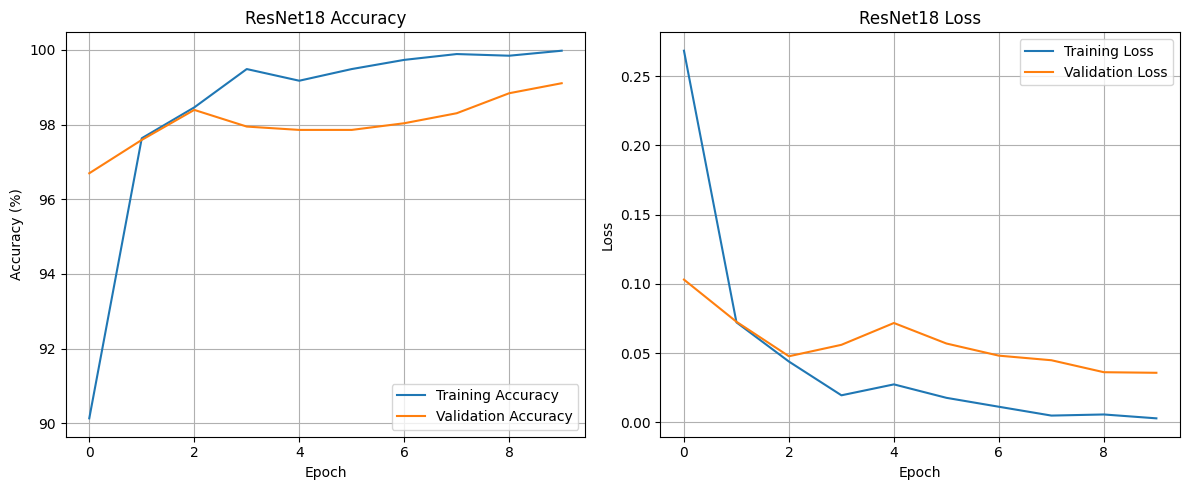

In [61]:
# ============================================
# 57. ResNet18 Training History
# ============================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(
    train_accuracies_resnet,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies_resnet,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet18 Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)

plt.plot(
    train_losses_resnet,
    label="Training Loss"
)

plt.plot(
    val_losses_resnet,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [62]:
# ============================================
# 58. Load Best ResNet18 Model
# ============================================

best_model_path_resnet = "/content/best_brain_tumor_resnet18.pth"

best_resnet = models.resnet18(
    weights=None
)

num_features = best_resnet.fc.in_features

best_resnet.fc = nn.Linear(
    num_features,
    4
)

best_resnet.load_state_dict(
    torch.load(
        best_model_path_resnet,
        map_location=device
    )
)

best_resnet = best_resnet.to(device)
best_resnet.eval()

print("Best ResNet18 model loaded successfully.")
print("Model device:", next(best_resnet.parameters()).device)

Best ResNet18 model loaded successfully.
Model device: cuda:0


In [63]:
# ============================================
# 59. Final ResNet18 Test Evaluation
# ============================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

all_predictions = []
all_labels = []

best_resnet.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = best_resnet(images)

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

final_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print("=" * 60)
print("FINAL RESNET18 TEST RESULTS")
print("=" * 60)

print(
    f"Test Accuracy: {final_accuracy * 100:.2f}%"
)

print(
    f"Correct Predictions: "
    f"{sum(np.array(all_predictions) == np.array(all_labels))}/"
    f"{len(all_labels)}"
)

FINAL RESNET18 TEST RESULTS
Test Accuracy: 94.56%
Correct Predictions: 1513/1600


In [64]:
# ============================================
# 60. Final Classification Report
# ============================================

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

      glioma     0.9969    0.8125    0.8953       400
  meningioma     0.9155    0.9750    0.9443       400
     notumor     0.9009    1.0000    0.9479       400
   pituitary     0.9851    0.9950    0.9900       400

    accuracy                         0.9456      1600
   macro avg     0.9496    0.9456    0.9444      1600
weighted avg     0.9496    0.9456    0.9444      1600



In [65]:
# ============================================
# 61. Final Confusion Matrix
# ============================================

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("Final Confusion Matrix:")
print(cm)

Final Confusion Matrix:
[[325  34  41   0]
 [  1 390   3   6]
 [  0   0 400   0]
 [  0   2   0 398]]


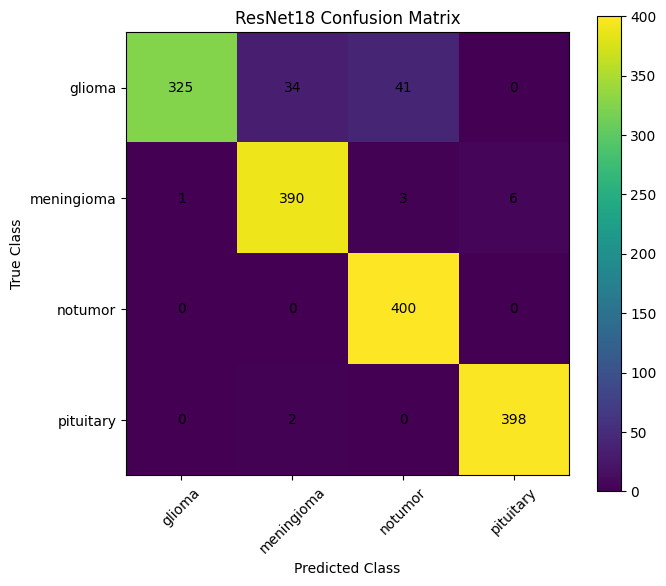

In [66]:
# ============================================
# 62. Confusion Matrix Visualization
# ============================================

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("ResNet18 Confusion Matrix")

for i in range(len(class_names)):
    for j in range(len(class_names)):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [67]:
# ============================================
# 63. Model Comparison
# ============================================

model_names = [
    "CNN V1",
    "CNN V2",
    "ResNet18"
]

test_accuracies = [
    75.00,
    76.69,
    final_accuracy * 100
]

for name, accuracy in zip(
    model_names,
    test_accuracies
):

    print(
        f"{name:<12} : {accuracy:.2f}%"
    )

CNN V1       : 75.00%
CNN V2       : 76.69%
ResNet18     : 94.56%


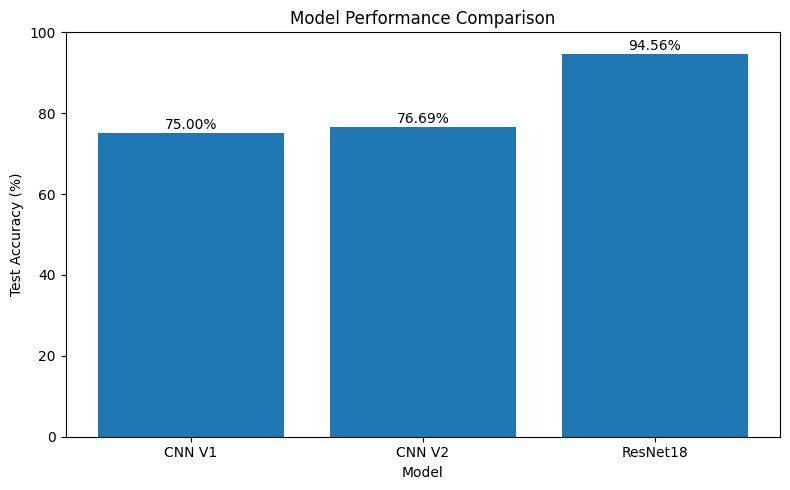

In [68]:
# ============================================
# 64. Model Accuracy Comparison
# ============================================

plt.figure(figsize=(8, 5))

plt.bar(
    model_names,
    test_accuracies
)

plt.ylabel("Test Accuracy (%)")
plt.xlabel("Model")
plt.title("Model Performance Comparison")

plt.ylim(0, 100)

for i, accuracy in enumerate(test_accuracies):

    plt.text(
        i,
        accuracy + 1,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [69]:
# ============================================
# 65. Save Final ResNet18 Model
# ============================================

final_model_path = "/content/final_brain_tumor_resnet18.pth"

torch.save(
    best_resnet.state_dict(),
    final_model_path
)

print("Final model saved at:")
print(final_model_path)

print(
    "File size:",
    round(os.path.getsize(final_model_path) / (1024 * 1024), 2),
    "MB"
)

Final model saved at:
/content/final_brain_tumor_resnet18.pth
File size: 42.72 MB


In [70]:
# ============================================
# 66. Download Final Model
# ============================================

from google.colab import files

files.download(final_model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
# ============================================
# 67. Single Image Prediction
# ============================================

from PIL import Image

def predict_image(
    image_path,
    model,
    transform,
    class_names,
    device
):

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Preprocess
    image_tensor = transform(image)

    # Add batch dimension
    input_tensor = image_tensor.unsqueeze(0).to(device)

    # Prediction
    model.eval()

    with torch.no_grad():

        output = model(input_tensor)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        confidence, predicted_class = (
            probabilities.max(dim=1)
        )

    predicted_class = predicted_class.item()
    confidence = confidence.item()

    print("=" * 60)
    print("BRAIN TUMOR MRI PREDICTION")
    print("=" * 60)

    print(
        "Predicted Class:",
        class_names[predicted_class]
    )

    print(
        "Confidence:",
        f"{confidence * 100:.2f}%"
    )

    print("=" * 60)

    return (
        predicted_class,
        confidence,
        probabilities.cpu().numpy()[0]
    )

In [72]:
# ============================================
# 68. Test Single Image Prediction
# ============================================

image_path = test_dataset.samples[0][0]

predicted_class, confidence, probabilities = predict_image(
    image_path=image_path,
    model=best_resnet,
    transform=resnet_eval_transform,
    class_names=class_names,
    device=device
)

print("\nClass probabilities:")

for class_name, probability in zip(
    class_names,
    probabilities
):

    print(
        f"{class_name:<12}: "
        f"{probability * 100:.2f}%"
    )

BRAIN TUMOR MRI PREDICTION
Predicted Class: notumor
Confidence: 79.89%

Class probabilities:
glioma      : 16.59%
meningioma  : 3.44%
notumor     : 79.89%
pituitary   : 0.09%


In [73]:
# ============================================
# 69. Prediction + Grad-CAM
# ============================================

def predict_with_gradcam(
    image_path,
    model,
    gradcam,
    transform,
    class_names,
    device
):

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Transform
    image_tensor = transform(image)

    # Add batch dimension
    input_tensor = image_tensor.unsqueeze(0).to(device)

    # Generate prediction
    model.eval()

    with torch.no_grad():

        output = model(input_tensor)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        confidence, predicted_class = (
            probabilities.max(dim=1)
        )

    predicted_class = predicted_class.item()
    confidence = confidence.item()

    # Grad-CAM
    heatmap, _ = gradcam.generate(
        input_tensor,
        class_index=predicted_class
    )

    # Convert image to numpy
    image_np = np.array(image)

    image_resized = cv2.resize(
        image_np,
        (224, 224)
    )

    # Resize heatmap
    heatmap_resized = cv2.resize(
        heatmap,
        (224, 224)
    )

    heatmap_uint8 = np.uint8(
        255 * heatmap_resized
    )

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    # Overlay
    overlay = cv2.addWeighted(
        image_resized,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    # Display
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)

    plt.imshow(image_resized)

    plt.title("Input MRI")

    plt.axis("off")

    plt.subplot(1, 3, 2)

    plt.imshow(heatmap_resized, cmap="jet")

    plt.title(
        f"Grad-CAM\n"
        f"{class_names[predicted_class]}"
    )

    plt.axis("off")

    plt.subplot(1, 3, 3)

    plt.imshow(overlay)

    plt.title(
        f"Prediction\n"
        f"{class_names[predicted_class]} "
        f"({confidence * 100:.2f}%)"
    )

    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("=" * 60)
    print("PREDICTION RESULT")
    print("=" * 60)
    print(
        "Predicted Class:",
        class_names[predicted_class]
    )
    print(
        "Confidence:",
        f"{confidence * 100:.2f}%"
    )
    print("=" * 60)

    return predicted_class, confidence

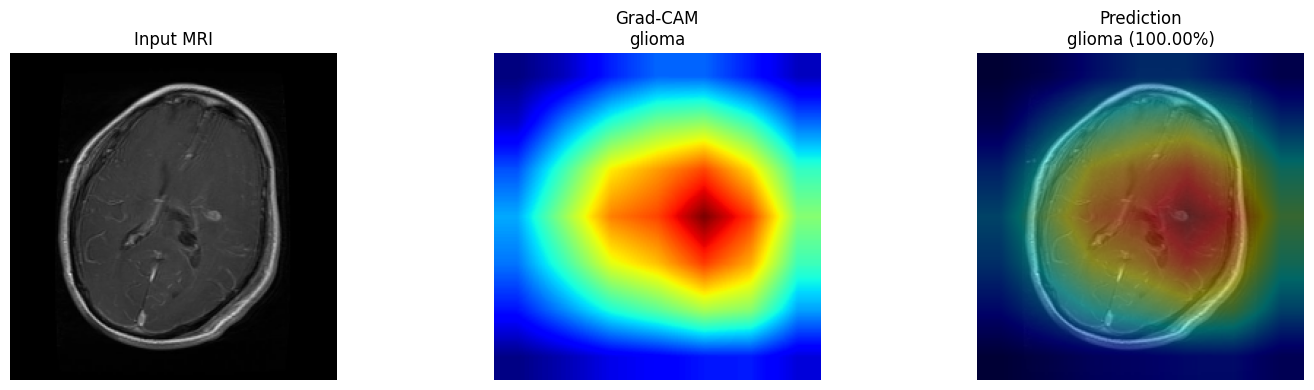

PREDICTION RESULT
Predicted Class: glioma
Confidence: 100.00%


(0, 0.9999972581863403)

In [74]:
# ============================================
# 70. Complete Prediction + Grad-CAM Test
# ============================================

image_path = test_dataset.samples[1][0]

predict_with_gradcam(
    image_path=image_path,
    model=best_resnet,
    gradcam=gradcam,
    transform=resnet_eval_transform,
    class_names=class_names,
    device=device
)

In [75]:
# ============================================
# 71. Upload MRI Image for Prediction
# ============================================

from google.colab import files

uploaded = files.upload()

uploaded_image_path = list(uploaded.keys())[0]

print("Uploaded image:", uploaded_image_path)

Saving sample.jpg to sample.jpg
Uploaded image: sample.jpg


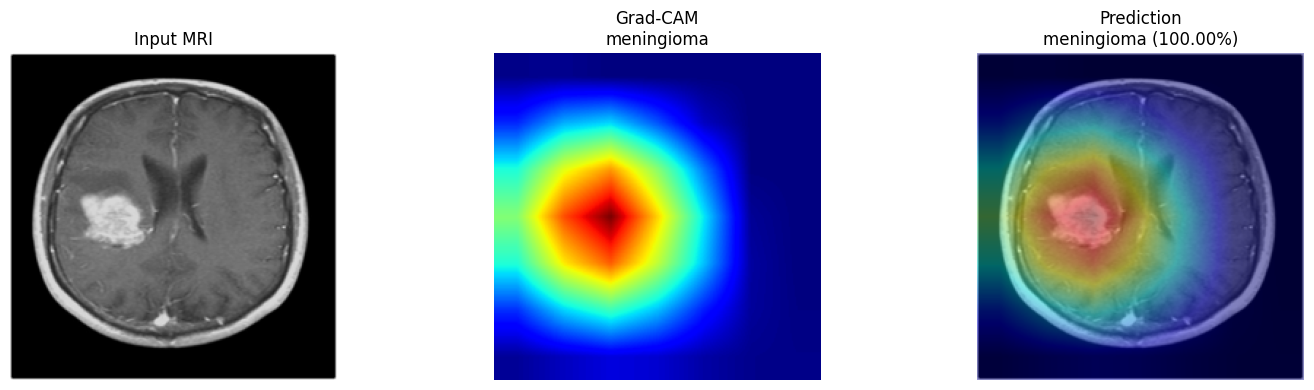

PREDICTION RESULT
Predicted Class: meningioma
Confidence: 100.00%


(1, 0.9999978542327881)

In [76]:
# ============================================
# 72. Predict Uploaded MRI + Grad-CAM
# ============================================

predict_with_gradcam(
    image_path=uploaded_image_path,
    model=best_resnet,
    gradcam=gradcam,
    transform=resnet_eval_transform,
    class_names=class_names,
    device=device
)

In [77]:
# ============================================
# 73. Save Grad-CAM Result
# ============================================

def save_gradcam_result(
    image_path,
    model,
    gradcam,
    transform,
    class_names,
    device,
    save_path
):

    image = Image.open(image_path).convert("RGB")

    image_tensor = transform(image)
    input_tensor = image_tensor.unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        output = model(input_tensor)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        confidence, predicted_class = probabilities.max(dim=1)

    predicted_class = predicted_class.item()
    confidence = confidence.item()

    heatmap, _ = gradcam.generate(
        input_tensor,
        class_index=predicted_class
    )

    image_np = np.array(image)

    image_resized = cv2.resize(
        image_np,
        (224, 224)
    )

    heatmap_resized = cv2.resize(
        heatmap,
        (224, 224)
    )

    heatmap_uint8 = np.uint8(
        255 * heatmap_resized
    )

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    overlay = cv2.addWeighted(
        image_resized,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image_resized)
    plt.title("Input MRI")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(
        f"{class_names[predicted_class]}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )
    plt.axis("off")

    plt.tight_layout()

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Result saved to:", save_path)

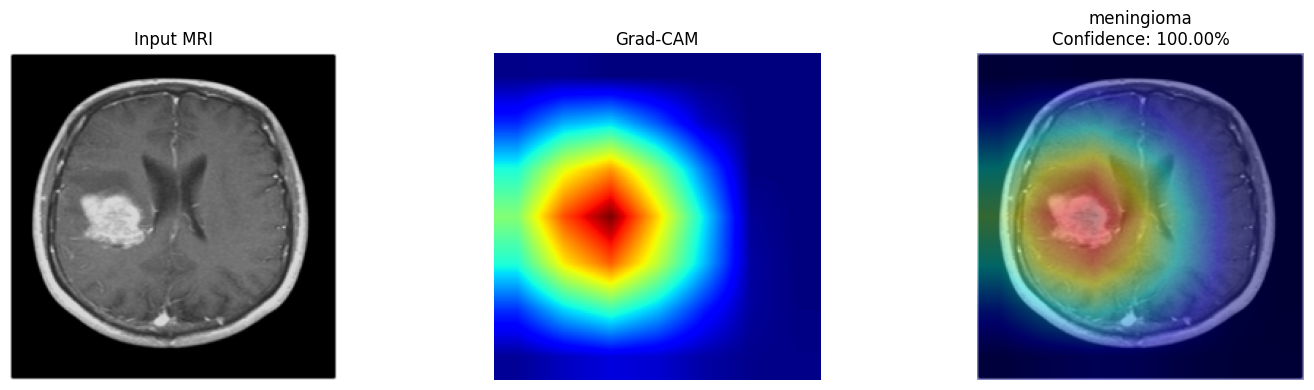

Result saved to: /content/final_gradcam_result.png


In [78]:
# ============================================
# 74. Save Final Grad-CAM Visualization
# ============================================

final_gradcam_path = (
    "/content/final_gradcam_result.png"
)

save_gradcam_result(
    image_path=uploaded_image_path,
    model=best_resnet,
    gradcam=gradcam,
    transform=resnet_eval_transform,
    class_names=class_names,
    device=device,
    save_path=final_gradcam_path
)

In [79]:
from google.colab import files

files.download(final_gradcam_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [80]:
# ============================================
# 75. Final Project Results
# ============================================

final_results = {
    "CNN V1 Test Accuracy": "75.00%",
    "CNN V2 Test Accuracy": "76.69%",
    "ResNet18 Test Accuracy": f"{final_accuracy * 100:.2f}%",
    "ResNet18 Best Validation Accuracy":
        f"{best_val_accuracy_resnet:.2f}%",
    "Test Images": len(test_dataset),
    "Number of Classes": len(class_names),
    "Classes": class_names
}

print("=" * 60)
print("FINAL PROJECT RESULTS")
print("=" * 60)

for key, value in final_results.items():
    print(f"{key}: {value}")

FINAL PROJECT RESULTS
CNN V1 Test Accuracy: 75.00%
CNN V2 Test Accuracy: 76.69%
ResNet18 Test Accuracy: 94.56%
ResNet18 Best Validation Accuracy: 99.11%
Test Images: 1600
Number of Classes: 4
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
